<a href="https://colab.research.google.com/github/vishakha122/dissertation/blob/main/hybridmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NOTEBOOK 3: Hybrid Model - MLP + ClinicalBERT
import time
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import json
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

PROCESSED_PATH = '/content/drive/MyDrive/MIMIC-IV/processed/'
MODEL_PATH     = '/content/drive/MyDrive/MIMIC-IV/models/'
import os
os.makedirs(MODEL_PATH, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [ ]:
#Load Preprocessed Data
structured = pd.read_csv(PROCESSED_PATH + 'structured_preprocessed.csv')
notes      = pd.read_csv(PROCESSED_PATH + 'notes_preprocessed.csv')

with open(PROCESSED_PATH + 'feature_cols.json') as f:
    feature_cols = json.load(f)

with open(PROCESSED_PATH + 'label_mapping.json') as f:
    label_mapping = json.load(f)

# Merge structured and notes on stay_id
df = structured.merge(notes[['stay_id', 'text_truncated']],
                      on='stay_id', how='left')
df['text_truncated'] = df['text_truncated'].fillna('[NO NOTE]')

print(f"Combined dataset: {df.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Label mapping: {label_mapping}")
print(f"Class distribution:\n{df['disposition_label'].value_counts()}")

Combined dataset: (425087, 32)
Number of features: 29
Label mapping: {'ADMITTED': 0, 'DISCHARGED': 1, 'OTHER': 2}
Class distribution:
disposition_label
1    255378
0    158010
2     11699
Name: count, dtype: int64


In [ ]:
#Train/Test Split (80/20)
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['disposition_label']  # ensures class balance in both splits
)

# Further split train into train/validation (80/20 of training set)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['disposition_label']
)

print(f"Train size:      {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size:       {len(test_df)}")

Train size:      272055
Validation size: 68014
Test size:       85018


In [ ]:
#Load ClinicalBERT Tokenizer

# This will download ClinicalBERT
tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')

print("ClinicalBERT tokenizer loaded ✓")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

ClinicalBERT tokenizer loaded ✓


In [ ]:
#Custom Dataset Class
class PatientDataset(Dataset):
    def __init__(self, dataframe, feature_cols, tokenizer, max_len=512):
        self.data       = dataframe.reset_index(drop=True)
        self.features   = feature_cols
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Structured features
        structured = torch.tensor(
            row[self.features].values.astype(np.float32),
            dtype=torch.float32
        )

        #  Tokenize clinical note
        encoding = self.tokenizer(
            str(row['text_truncated']),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        #  Label
        label = torch.tensor(row['disposition_label'], dtype=torch.long)

        return {
            'structured':   structured,
            'input_ids':    encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':        label
        }

print("Dataset class defined ✓")

Dataset class defined ✓


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

print("Applying undersampling to balance classes...")

#  Extract features and labels
X_train = train_df[feature_cols].values
y_train = train_df['disposition_label'].values

print("\nClass distribution BEFORE undersampling:")
class_counts = pd.Series(y_train).value_counts().sort_index()
print(class_counts)

inv_mapping = {v: k for k, v in label_mapping.items()}
for label, count in class_counts.items():
    print(f"  {inv_mapping[label]:15s}: {count:,} ({count/len(y_train)*100:.1f}%)")

#Apply Undersampling
#Reduce majority classes to balance with minority
rus = RandomUnderSampler(
    sampling_strategy={
        0: 50000,   # ADMITTED - reduce from 101k to 50k
        1: 60000,   # DISCHARGED - reduce from 163k to 60k
        2: int((y_train == 2).sum())  # OTHER - keep all (~7.5k)
    },
    random_state=42
)

print("\nRunning undersampling (instant)...")
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

print("\nClass distribution AFTER undersampling:")
class_counts_after = pd.Series(y_resampled).value_counts().sort_index()
print(class_counts_after)
for label, count in class_counts_after.items():
    print(f"  {inv_mapping[label]:15s}: {count:,} ({count/len(y_resampled)*100:.1f}%)")

# Calculate imbalance improvement
imbalance_before = class_counts.max() / class_counts.min()
imbalance_after = class_counts_after.max() / class_counts_after.min()
print(f"\nImbalance ratio:")
print(f"  BEFORE: {imbalance_before:.1f}:1")
print(f"  AFTER:  {imbalance_after:.1f}:1")

# Create undersampled dataframe
print("\nCreating undersampled dataframe...")

# Get indices of kept samples
kept_indices = rus.sample_indices_

# Use those indices to get corresponding rows (includes text!)
train_df_undersampled = train_df.iloc[kept_indices].reset_index(drop=True)

print(f"\n Undersampling complete!")
print(f"Original training size:    {len(train_df):,}")
print(f"Undersampled training size: {len(train_df_undersampled):,}")
print(f"Validation size:           {len(val_df):,}")
print(f"Test size:                 {len(test_df):,}")

# Create dataloaders
BATCH_SIZE = 16

train_dataset_under = PatientDataset(train_df_undersampled, feature_cols, tokenizer)
val_dataset         = PatientDataset(val_df, feature_cols, tokenizer)

train_loader_under = DataLoader(train_dataset_under, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=2, pin_memory=True)
val_loader         = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain batches (undersampled): {len(train_loader_under):,}")
print(f"Val batches:                  {len(val_loader):,}")

#  Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

train_labels_under = train_df_undersampled['disposition_label'].values

class_weights_under = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_under),
    y=train_labels_under
)

weights_tensor_under = torch.tensor(class_weights_under, dtype=torch.float32).to(device)

print("\nClass weights (undersampled):")
for i, weight in enumerate(class_weights_under):
    print(f"  {inv_mapping[i]:15s}: {weight:.2f}x")

criterion_under = nn.CrossEntropyLoss(weight=weights_tensor_under)

print("\nUndersampled dataset ready for training!")

Applying undersampling to balance classes...

Class distribution BEFORE undersampling:
0    101126
1    163442
2      7487
Name: count, dtype: int64
  ADMITTED       : 101,126 (37.2%)
  DISCHARGED     : 163,442 (60.1%)
  OTHER          : 7,487 (2.8%)

Running undersampling (instant)...

Class distribution AFTER undersampling:
0    50000
1    60000
2     7487
Name: count, dtype: int64
  ADMITTED       : 50,000 (42.6%)
  DISCHARGED     : 60,000 (51.1%)
  OTHER          : 7,487 (6.4%)

Imbalance ratio:
  BEFORE: 21.8:1
  AFTER:  8.0:1

Creating undersampled dataframe...

✓ Undersampling complete!
Original training size:    272,055
Undersampled training size: 117,487
Validation size:           68,014
Test size:                 85,018

Train batches (undersampled): 7,343
Val batches:                  4,251

Class weights (undersampled):
  ADMITTED       : 0.78x
  DISCHARGED     : 0.65x
  OTHER          : 5.23x

✓ Undersampled dataset ready for training!

Next: Run training loop using train_

In [ ]:
# Define Hybrid Model Architecture
class HybridModel(nn.Module):
    def __init__(self, num_structured_features, num_classes, dropout=0.3):
        super(HybridModel, self).__init__()

        #  ClinicalBERT branch
        self.bert = AutoModel.from_pretrained(
            'emilyalsentzer/Bio_ClinicalBERT')
        bert_hidden_size = 768  # ClinicalBERT output size

        # Freeze early BERT layers to speed up training
        # Only fine-tune last 2 transformer layers
        for name, param in self.bert.named_parameters():
            if 'encoder.layer.11' not in name and \
               'encoder.layer.10' not in name and \
               'pooler' not in name:
                param.requires_grad = False

        #  MLP branch (structured data)
        self.mlp = nn.Sequential(
            nn.Linear(num_structured_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        mlp_output_size = 64

        #  Fusion + Classification head
        fusion_input_size = bert_hidden_size + mlp_output_size

        self.classifier = nn.Sequential(
            nn.Linear(fusion_input_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
            # No softmax here - CrossEntropyLoss applies it internally
        )

    def forward(self, structured, input_ids, attention_mask):
        #  Text embedding via ClinicalBERT
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Mean pooling over token embeddings
        token_embeddings = bert_output.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).float()
        text_embedding = (token_embeddings * mask_expanded).sum(1) \
                       / mask_expanded.sum(1).clamp(min=1e-9)

        #  Structured embedding via MLP
        structured_embedding = self.mlp(structured)

        #  Concatenate and classify
        combined = torch.cat([text_embedding, structured_embedding], dim=1)
        logits   = self.classifier(combined)

        return logits

NUM_CLASSES  = len(label_mapping)
NUM_FEATURES = len(feature_cols)

model = HybridModel(
    num_structured_features=NUM_FEATURES,
    num_classes=NUM_CLASSES
).to(device)

print(f"Model created ✓")
print(f"Structured features: {NUM_FEATURES}")
print(f"Number of classes:   {NUM_CLASSES}")

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created ✓
Structured features: 29
Number of classes:   3
Trainable parameters: 15,045,059 / 108,588,995


In [ ]:
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

#  Class Weighting for undersampled data
train_labels_under = train_df_undersampled['disposition_label'].values

class_weights_under = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_under),
    y=train_labels_under
)

weights_tensor_under = torch.tensor(class_weights_under, dtype=torch.float32).to(device)

print("\nClass weights (undersampled data):")
inv_mapping = {v: k for k, v in label_mapping.items()}
for i, weight in enumerate(class_weights_under):
    print(f"  {inv_mapping[i]:15s}: {weight:.2f}x")

criterion_under = nn.CrossEntropyLoss(weight=weights_tensor_under)

#  Optimizer & Scheduler
optimizer = AdamW([
    {'params': model.bert.parameters(),       'lr': 2e-5},
    {'params': model.mlp.parameters(),        'lr': 1e-3},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

NUM_EPOCHS = 5

#  Training Functions
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        structured    = batch['structured'].to(device)
        input_ids     = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels        = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(structured, input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            structured     = batch['structured'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(structured, input_ids, attention_mask)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds), all_preds, all_labels

print("\n✓ Everything loaded and ready to train with undersampled data!")
print(f"Training samples: {len(train_df_undersampled):,}")
print(f"Using: train_loader_under and criterion_under")


Class weights (undersampled data):
  ADMITTED       : 0.78x
  DISCHARGED     : 0.65x
  OTHER          : 5.23x

✓ Everything loaded and ready to train with undersampled data!
Training samples: 117,487
Using: train_loader_under and criterion_under


In [ ]:
# Training Loop with Undersampled Data
from sklearn.utils.class_weight import compute_class_weight
import time

# Use undersampled class weights
print("Class weights (undersampled data):")
inv_mapping = {v: k for k, v in label_mapping.items()}
for i, weight in enumerate(class_weights_under):
    print(f"  {inv_mapping[i]:15s}: {weight:.2f}x")

print("\n✓ Using criterion_under")

best_val_loss = float('inf')
history       = []

print(f"\nTraining on undersampled data")
print(f"Training samples: {len(train_df_undersampled):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}\n")

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # Use undersampled loader and criterion
    train_loss, train_acc = train_epoch(
        model, train_loader_under, optimizer, criterion_under, device)
    val_loss, val_acc, _, _ = eval_epoch(
        model, val_loader, criterion_under, device)

    scheduler.step(val_loss)
    elapsed = time.time() - start

    history.append({
        'epoch':      epoch + 1,
        'train_loss': train_loss,
        'train_acc':  train_acc,
        'val_loss':   val_loss,
        'val_acc':    val_acc
    })

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed/60:.1f} min")

    #  Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   MODEL_PATH + 'best_hybrid_model_under_3class.pt')
        print(f" Best model saved")

    #  Save checkpoint every epoch
    torch.save({
        'epoch':                epoch + 1,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss':             val_loss,
        'history':              history
    }, MODEL_PATH + f'checkpoint_under_3class_epoch_{epoch+1}.pt')
    print(f" Checkpoint saved")

#  Save training history
pd.DataFrame(history).to_csv(
    MODEL_PATH + 'training_history_under_3class.csv', index=False)

print("\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")

Class weights (undersampled data):
  ADMITTED       : 0.78x
  DISCHARGED     : 0.65x
  OTHER          : 5.23x

✓ Using criterion_under

Training on undersampled data
Training samples: 117,487
Batch size: 16
Epochs: 5

Epoch 1/5 | Train Loss: 0.6059 | Train Acc: 0.8946 | Val Loss: 0.3563 | Val Acc: 0.9117 | Time: 45.3 min
  → Best model saved ✓
  → Checkpoint saved ✓
Epoch 2/5 | Train Loss: 0.5511 | Train Acc: 0.9050 | Val Loss: 0.3419 | Val Acc: 0.9096 | Time: 45.3 min
  → Best model saved ✓
  → Checkpoint saved ✓
Epoch 3/5 | Train Loss: 0.5430 | Train Acc: 0.9065 | Val Loss: 0.3814 | Val Acc: 0.9213 | Time: 45.3 min
  → Checkpoint saved ✓
Epoch 4/5 | Train Loss: 0.5377 | Train Acc: 0.9086 | Val Loss: 0.3773 | Val Acc: 0.9358 | Time: 45.3 min
  → Checkpoint saved ✓
Epoch 5/5 | Train Loss: 0.5272 | Train Acc: 0.9098 | Val Loss: 0.3653 | Val Acc: 0.9134 | Time: 45.3 min
  → Checkpoint saved ✓

Training complete!
Best validation loss: 0.3419


Loading best model (Epoch 2, val_loss=0.3419)...

Evaluating on 85,018 test samples...

TEST SET PERFORMANCE - UNDERSAMPLED 3-CLASS HYBRID MODEL

Overall Metrics:
  Accuracy:          0.9093
  Balanced Accuracy: 0.7975
  MCC:               1.0000

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    ADMITTED     0.9779    0.9620    0.9699     31602
  DISCHARGED     0.9669    0.8937    0.9288     51076
       OTHER     0.1869    0.5368    0.2773      2340

    accuracy                         0.9093     85018
   macro avg     0.7106    0.7975    0.7253     85018
weighted avg     0.9495    0.9093    0.9262     85018


----------------------------------------------------------------------
AUROC SCORES (One-vs-Rest)
----------------------------------------------------------------------
  ADMITTED       : 0.9910
  DISCHARGE

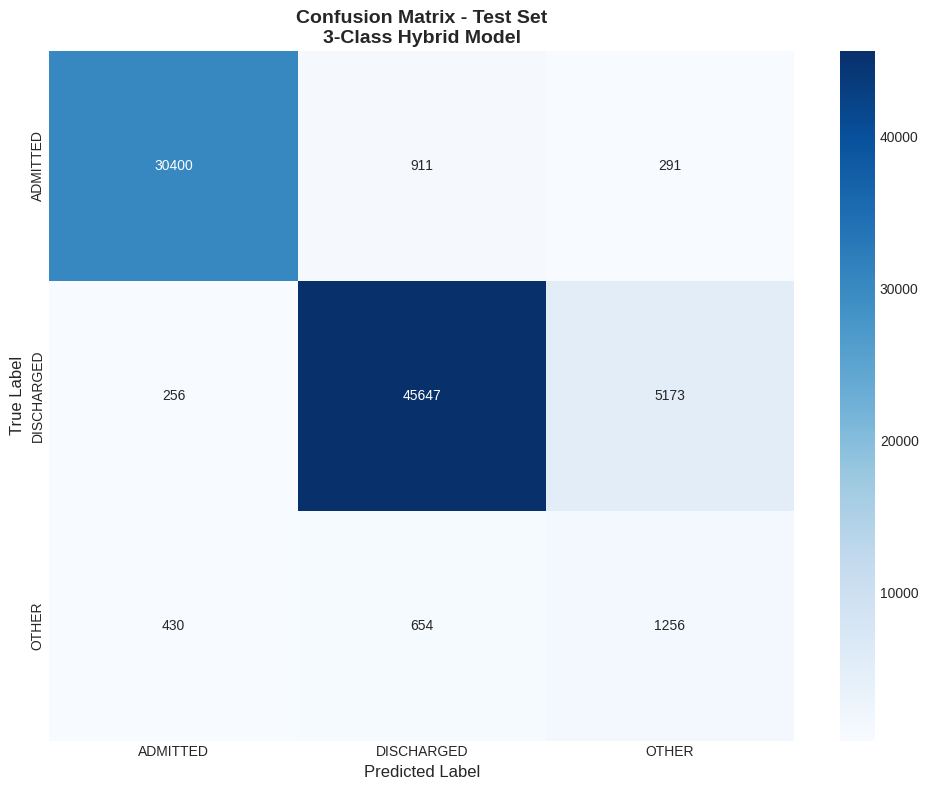

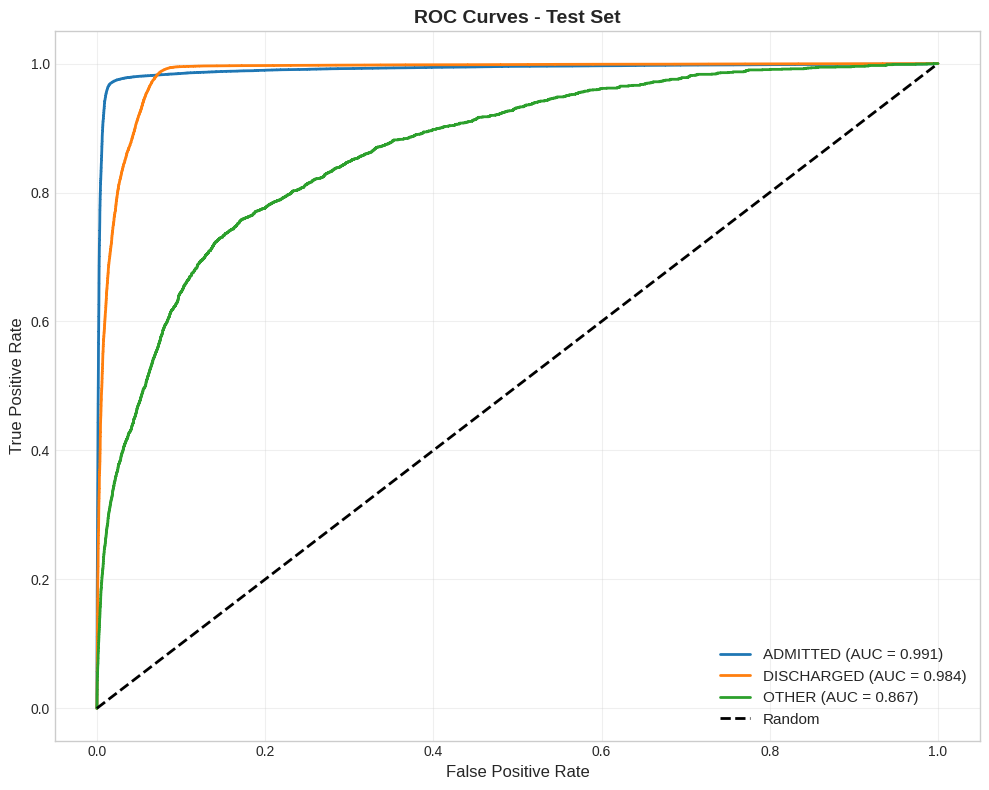

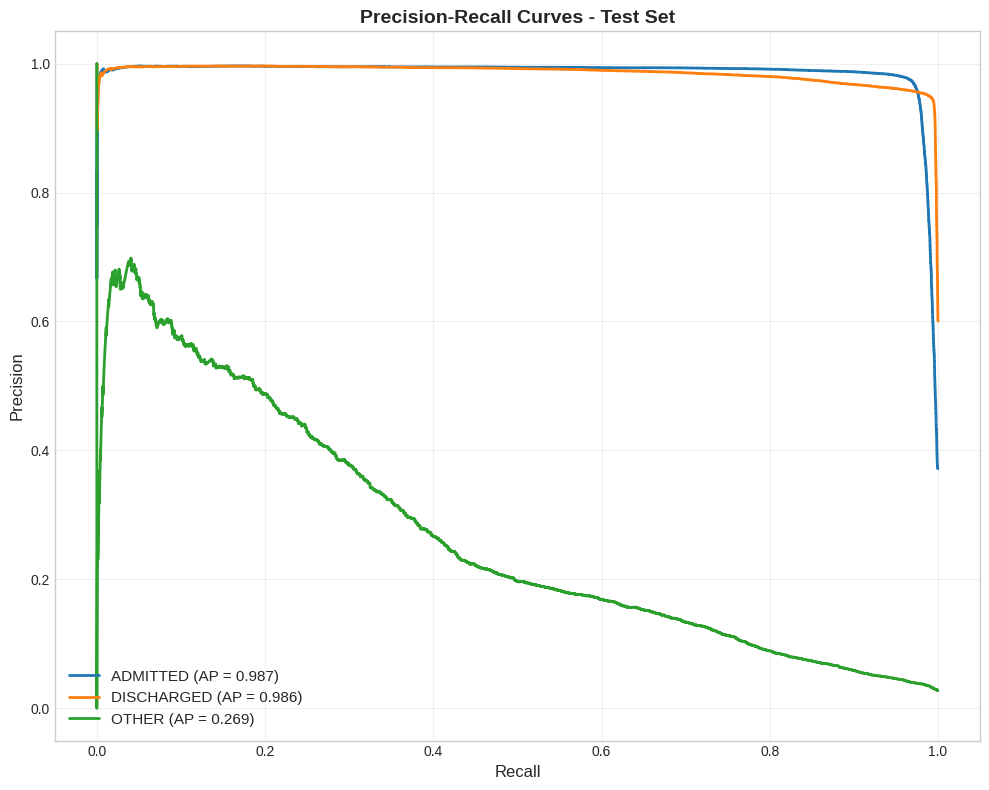


SUMMARY TABLE
     Class  Precision   Recall  F1-Score    AUROC  Avg Precision  Support
  ADMITTED   0.977932 0.961964  0.969883 0.991043       0.986591    31602
DISCHARGED   0.966852 0.893707  0.928842 0.984123       0.986090    51076
     OTHER   0.186905 0.536752  0.277263 0.867394       0.268541     2340
 Macro Avg   0.710563 0.797475  0.725329 0.947520       0.747074    85018

✓ Test evaluation complete!
✓ Results saved to: /content/drive/MyDrive/MIMIC-IV/models/


In [ ]:

# Test Set Evaluation - Undersampled 3-Class Model
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score, matthews_corrcoef,
                              balanced_accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#  Load Best Model
print("Loading best model (Epoch 2, val_loss=0.3419)...")
model.load_state_dict(torch.load(MODEL_PATH + 'best_hybrid_model_under_3class.pt'))
model.eval()

#  Create Test Loader
test_dataset = PatientDataset(test_df, feature_cols, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"\nEvaluating on {len(test_df):,} test samples...")

#  Get Predictions and Probabilities
all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        structured = batch['structured'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(structured, input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

#  Calculate Metrics
inv_mapping = {v: k for k, v in label_mapping.items()}
target_names = [inv_mapping[i] for i in range(len(label_mapping))]

print("TEST SET PERFORMANCE - UNDERSAMPLED 3-CLASS HYBRID MODEL")

# Overall metrics
test_acc = np.mean(all_preds == all_labels)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
mcc = matthews_corrcoef(all_labels, all_labels)

print(f"\nOverall Metrics:")
print(f"  Accuracy:          {test_acc:.4f}")
print(f"  Balanced Accuracy: {balanced_acc:.4f}")
print(f"  MCC:               {mcc:.4f}")

#  Classification Report
print("\n" + "-"*70)
print("CLASSIFICATION REPORT")
print("-"*70)
print(classification_report(all_labels, all_preds,
                             target_names=target_names,
                             digits=4))

#  Per-Class AUROC
print("\n" + "-"*70)
print("AUROC SCORES (One-vs-Rest)")
print("-"*70)

auroc_scores = {}
for i, class_name in enumerate(target_names):
    y_true_binary = (all_labels == i).astype(int)
    y_score = all_probs[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_score)
    roc_auc = auc(fpr, tpr)
    auroc_scores[class_name] = roc_auc

    print(f"  {class_name:15s}: {roc_auc:.4f}")

macro_auroc = np.mean(list(auroc_scores.values()))
print(f"\n  Macro Avg AUROC:   {macro_auroc:.4f}")

#  Per-Class Average Precision
print("\n" + "-"*70)
print("AVERAGE PRECISION SCORES")
print("-"*70)

ap_scores = {}
for i, class_name in enumerate(target_names):
    y_true_binary = (all_labels == i).astype(int)
    y_score = all_probs[:, i]

    ap = average_precision_score(y_true_binary, y_score)
    ap_scores[class_name] = ap

    print(f"  {class_name:15s}: {ap:.4f}")

macro_ap = np.mean(list(ap_scores.values()))
print(f"\n  Macro Avg AP:      {macro_ap:.4f}")

#  Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

print("\n" + "-"*70)
print("CONFUSION MATRIX")
print("-"*70)
print(pd.DataFrame(cm,
                   index=[f"True {name}" for name in target_names],
                   columns=[f"Pred {name}" for name in target_names]))

#  Per-Class Breakdown
print("\n" + "-"*70)
print("PER-CLASS DETAILED BREAKDOWN")
print("-"*70)

report_dict = classification_report(all_labels, all_preds,
                                     target_names=target_names,
                                     output_dict=True)

for i, class_name in enumerate(target_names):
    print(f"\n{class_name}:")
    print(f"  Precision:  {report_dict[class_name]['precision']:.4f}")
    print(f"  Recall:     {report_dict[class_name]['recall']:.4f}")
    print(f"  F1-Score:   {report_dict[class_name]['f1-score']:.4f}")
    print(f"  AUROC:      {auroc_scores[class_name]:.4f}")
    print(f"  Avg Prec:   {ap_scores[class_name]:.4f}")
    print(f"  Support:    {int(report_dict[class_name]['support'])}")

#  Visualizations

# 1. Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            ax=ax)
ax.set_title('Confusion Matrix - Test Set\n3-Class Hybrid Model',
             fontsize=14, weight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_PATH + 'test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, class_name in enumerate(target_names):
    y_true_binary = (all_labels == i).astype(int)
    y_score = all_probs[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'{class_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Test Set', fontsize=14, weight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_PATH + 'test_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Precision-Recall Curves
fig, ax = plt.subplots(figsize=(10, 8))

for i, class_name in enumerate(target_names):
    y_true_binary = (all_labels == i).astype(int)
    y_score = all_probs[:, i]

    precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
    ap = average_precision_score(y_true_binary, y_score)

    ax.plot(recall, precision, color=colors[i], lw=2,
            label=f'{class_name} (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Test Set', fontsize=14, weight='bold')
ax.legend(loc="lower left", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_PATH + 'test_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#  Summary Table
summary_data = []
for class_name in target_names:
    summary_data.append({
        'Class': class_name,
        'Precision': report_dict[class_name]['precision'],
        'Recall': report_dict[class_name]['recall'],
        'F1-Score': report_dict[class_name]['f1-score'],
        'AUROC': auroc_scores[class_name],
        'Avg Precision': ap_scores[class_name],
        'Support': int(report_dict[class_name]['support'])
    })

# Add macro averages
summary_data.append({
    'Class': 'Macro Avg',
    'Precision': report_dict['macro avg']['precision'],
    'Recall': report_dict['macro avg']['recall'],
    'F1-Score': report_dict['macro avg']['f1-score'],
    'AUROC': macro_auroc,
    'Avg Precision': macro_ap,
    'Support': len(all_labels)
})

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(MODEL_PATH + 'test_performance_summary.csv', index=False)

print("\n" + "="*70)
print("✓ Test evaluation complete!")
print(f"✓ Results saved to: {MODEL_PATH}")
print("="*70)